In [1]:
"""Test cross-polarized scattering"""
import sys
sys.path.append('../../../')
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.constants as sci_const
import matplotlib.pyplot as plt

from mores.interface.IEM_crosspol_upward import sigma0_VH_IEM

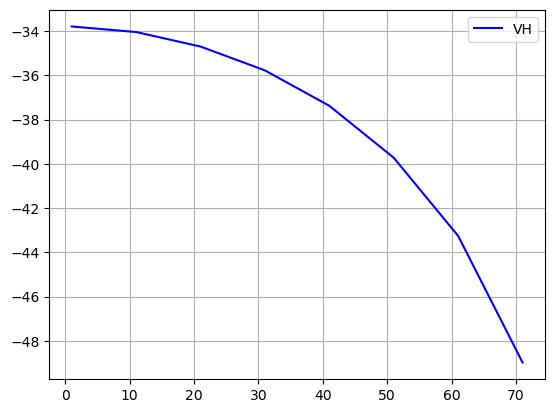

In [3]:
f = 1e9
kdel = 0.6
kcor = 3.0
epsr = 3.0 - 0.1j
c = sci_const.speed_of_light
Lambda = c / f
k = 2 * np.pi / Lambda

delta = kdel / k
corr_len = kcor / k

theta_is = np.arange(1, 80, 10)

N = len(theta_is)
vhs = np.zeros(N)
for i in range(N):
    theta_i = theta_is[i]
    sigma0_vh = sigma0_VH_IEM(f, theta_i, epsr, delta, corr_len, spectrum='exp', x=1.5, shadow_flag=False)
    vhs[i] = 10 * np.log10(sigma0_vh)

# show
fig, ax = plt.subplots()
ax.plot(theta_is, vhs, 'b-', label='VH')
ax.grid()
# ax.set_ylim(-40, -10)
plt.legend()
plt.show()